In [22]:
import os
import timm
import torch
import numpy as np

import utils.data as data_utils
from utils.predict import PredictPlants
from utils.evaluate import EvalClassification

random_seed = 8

## Model

In [23]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"
best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"

# timm_model_name = "convnextv2_atto.fcmae_ft_in1k"
# best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_11-55--18_atto3M_stratified_convnextv2_atto.fcmae_ft_in1k.pth"

In [24]:
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))

model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")

Using device: cuda
GPU:  NVIDIA RTX A500 Laptop GPU
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Compare Methods

In [25]:
hand_dataloader = data_utils.get_test_dataloader()
_, _, test_dataloader = data_utils.get_3_dataloaders(batch_size=1)

# comparison_dataloader = test_dataloader
comparison_dataloader = hand_dataloader

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
 Total dataset size 	: 221
 Train dataset size 	: 132
 Val dataset size 	: 44
 Test dataset size 	: 45



In [ ]:
baseline_evaluator = EvalClassification(
    model_name = timm_model_name,
    model_file = best_model_path,
    dataloader= comparison_dataloader
)
print("\nEvaluating direct predictions for baseline...")
baseline_evaluator.evaluate()
baseline_evaluator.get_accuracy()

predictor = PredictPlants(
    model_name = timm_model_name,
    model_file = best_model_path
)

print("\nEvaluating with critical review upon confusion...")
critical_evalator = predictor.evaluate_with_predict_fn(
    dataloader= comparison_dataloader
)
critical_evalator.get_accuracy()

critical_evalator.print_definitions()


Definitions of Metrics:
TP:  True Positives - Invasive species correctly classified as Invasive
TN:  True Negatives - Non-Invasive species correctly classified as Non-Invasive
FP:  False Positives - Non-Invasive species incorrectly classified as Invasive
FN:  False Negatives - Invasive species incorrectly classified as Non-Invasive
FPR:  False Positive Rate - Proportion of Non-Invasive species incorrectly classified as Invasive
FNR:  False Negative Rate - Proportion of Invasive species incorrectly classified as Non-Invasive {IMPORTANT!}
TNR:  True Negative Rate (Specificity) - Proportion of Non-Invasive species correctly classified
TPR:  True Positive Rate (Recall or Sensitivity) - Proportion of Invasive species correctly classified
PPV:  Positive Predictive Value (Precision) - Proportion of predicted Invasive species that are actually Invasive
NPV:  Negative Predictive Value - Proportion of Non-Invasive predictions that are actually Non-Invasive
F1 Score:  Harmonic mean of Precision 

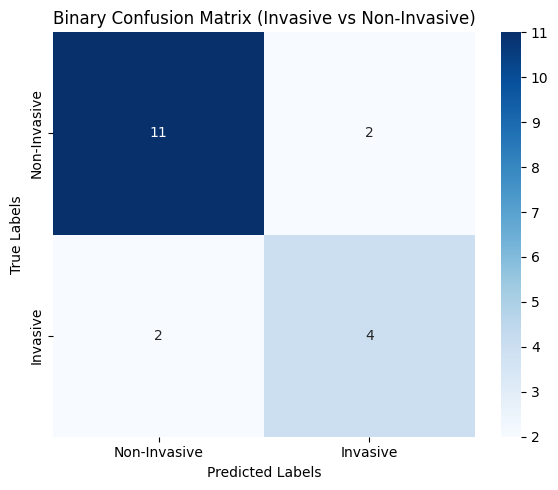


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        4 | False Positive Rate (FPR)      |    0.1538 | Negative Predictive Value (NPV) |    0.8462 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       11 | False Negative Rate (FNR)      |    0.3333 | Positive " (PPV or Precision)   |    0.6667 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        2

In [7]:
critical_evalator.get_binary_confusion_matrix()
crit_bin = critical_evalator.get_binary_metrics()

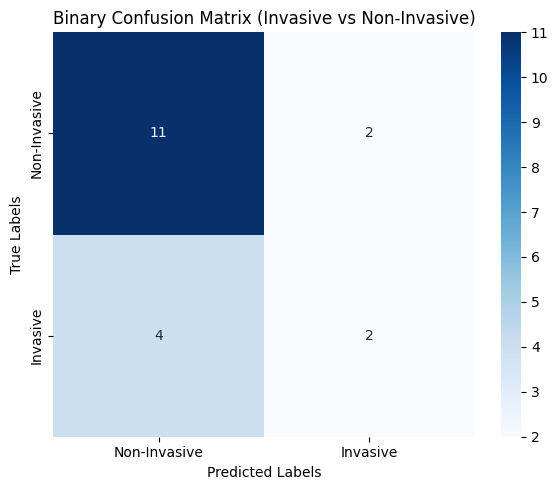


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        2 | False Positive Rate (FPR)      |    0.1538 | Negative Predictive Value (NPV) |    0.7333 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       11 | False Negative Rate (FNR)      |    0.6667 | Positive " (PPV or Precision)   |    0.5    |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        2

In [ ]:
baseline_evaluator.get_binary_confusion_matrix()
baseline_bin = baseline_evaluator.get_binary_metrics()

In [ ]:
crit_bin = critical_evalator.get_binary_metrics()
baseline_bin = baseline_evaluator.get_binary_metrics()

fnr_baseline = baseline_bin['FNR']
fnr_crit = crit_bin['FNR']
print("FNR - False Negative Rate: Percentage of actual actual Invasive plants that were predicted as Non-Invasive.")
print(f"Baseline FNR: {100*(fnr_baseline):.2f} \nCritical FNR: {100*(fnr_crit):.2f}")

if fnr_crit < fnr_baseline:
    print(f"Critical review reduced the FNR by {100*(fnr_baseline - fnr_crit):.2f}%.")
else: 
    print(f"Critical review did not reduce the FNR.")

FNR - False Negative Rate: Percentage of actual actual Invasive plants that were predicted as Non-Invasive.
Baseline FNR: 66.67 
Critical FNR: 33.33
Critical review reduced the FNR by 33.33%.


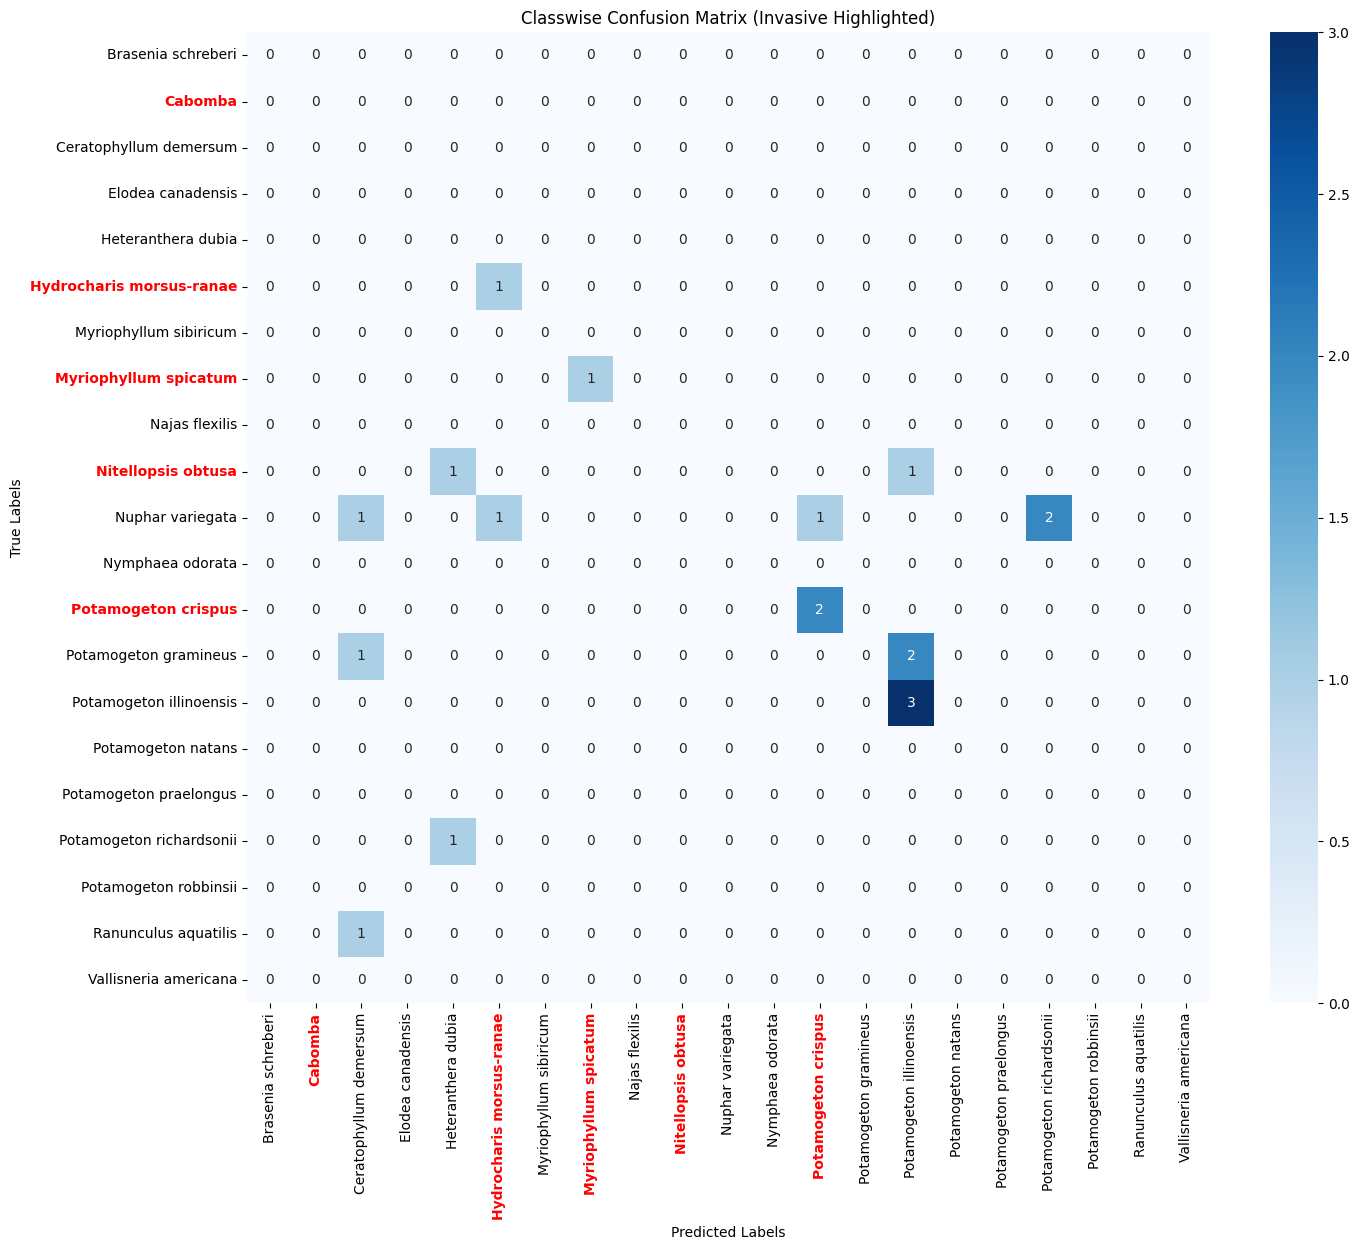


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+============+=====================+===========+
| Brasenia schreberi       |         0 |    0 |    0 |    0 |    0        |              0 |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Cabomba                  |         0 |    0 |    0 |    0 |    0        |              0 |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+


In [10]:
critical_evalator.get_classwise_confusion_matrix()
classwise_crit = critical_evalator.get_classwise_metrics()

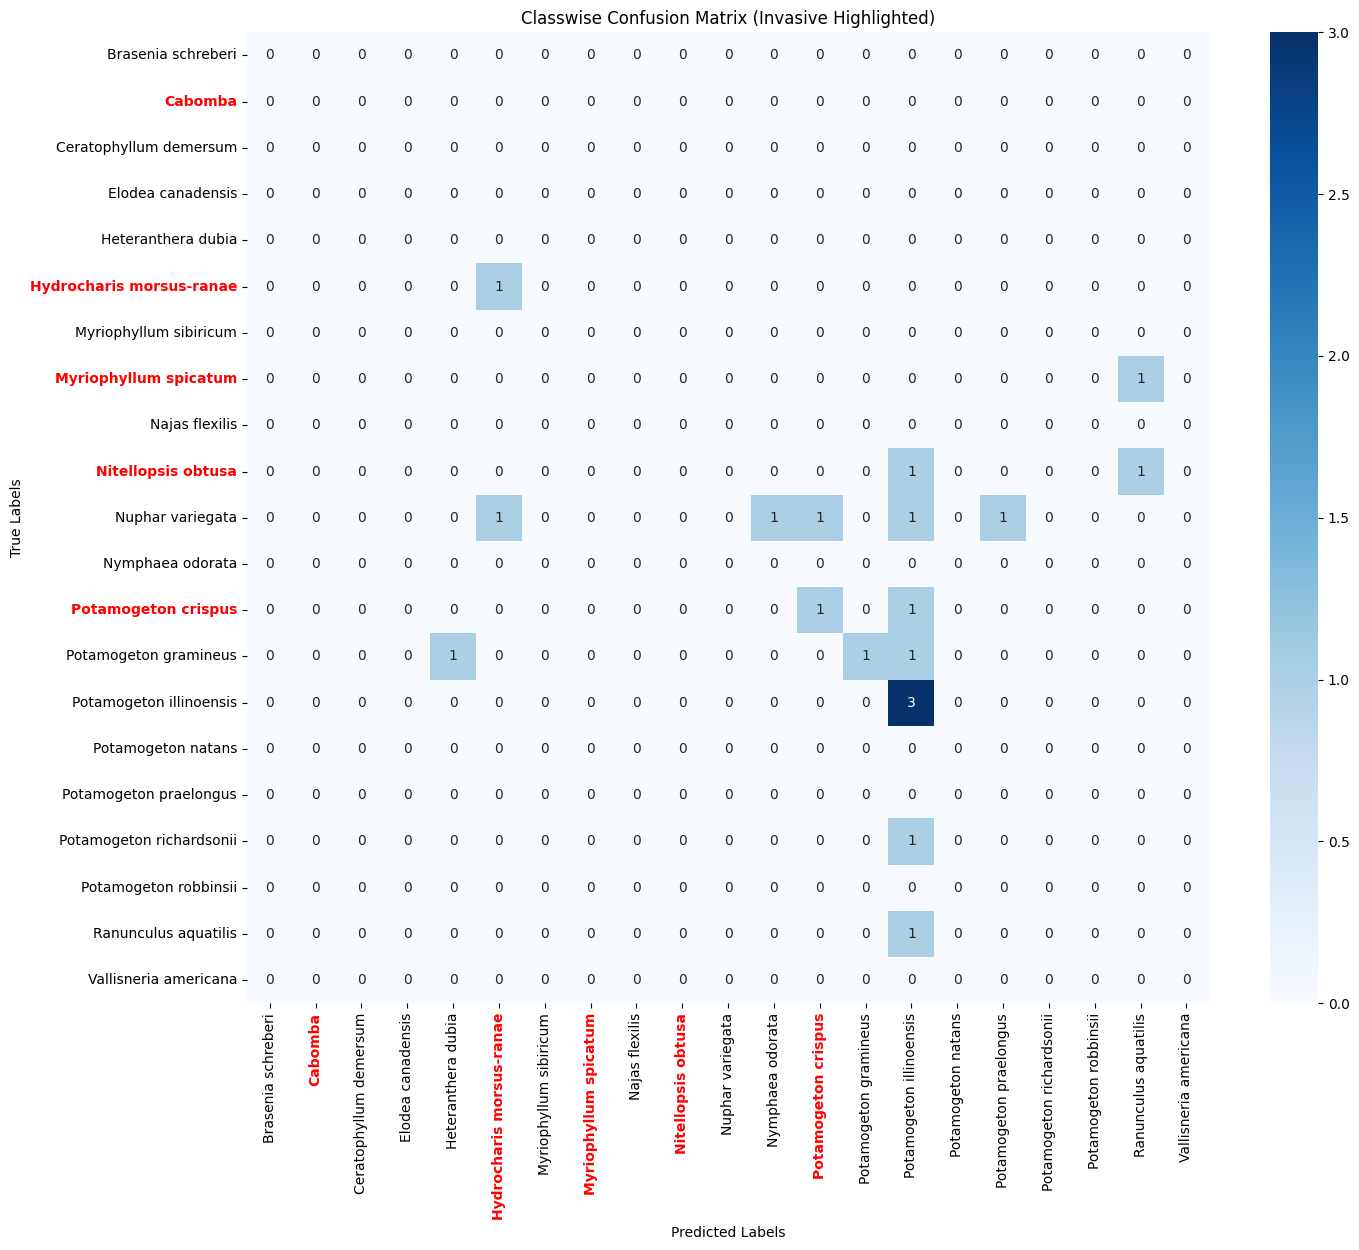


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+============+=====================+===========+
| Brasenia schreberi       |         0 |    0 |    0 |    0 |    0        |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Cabomba                  |         0 |    0 |    0 |    0 |    0        |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+


In [11]:
baseline_evaluator.get_classwise_confusion_matrix()
classwise_base = baseline_evaluator.get_classwise_metrics()